# 西班牙语-英语机器翻译实验

## 毕业设计实验代码

### 实验概述
本实验基于西班牙语-英语平行语料（spa.txt），实现序列到序列（Seq2Seq）的机器翻译任务，
对比基于RNN的Seq2Seq+Attention模型与基于Transformer的翻译模型。

### 与文本分类任务的区别
| 对比维度 | 文本分类 | 机器翻译 |
|----------|----------|----------|
| 任务类型 | 序列→标签 | 序列→序列 |
| 模型结构 | 仅Encoder | Encoder + Decoder |
| 输出 | 固定类别数 | 可变长度序列 |
| 解码方式 | 无 | 自回归逐词生成 |
| 评价指标 | Accuracy/F1 | BLEU分数 |

### 实验模型
| 序号 | 模型 | 核心机制 |
|------|------|----------|
| 1 | Seq2Seq + Attention (GRU) | RNN编码器-解码器 + Bahdanau注意力 |
| 2 | Transformer | 自注意力 + 交叉注意力 |

### 数据集
- spa.txt: 英语-西班牙语平行语料
- 约118,964对翻译句对
- 格式: 英语\t西班牙语（Tab分隔）
- 翻译方向: 英语 → 西班牙语

## 第1部分：环境配置与依赖导入

In [1]:
# ============================================================================
# 第1部分：导入所有依赖库
# ============================================================================

import re
import math
import time
import random
import warnings
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os
from nltk.translate.bleu_score import corpus_bleu as nltk_corpus_bleu
from nltk.translate.bleu_score import SmoothingFunction
if os.name == 'nt':
    os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')
# --- 设置matplotlib支持中文显示 ---
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# --- PyTorch ---
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torch.nn.functional as F

warnings.filterwarnings('ignore')

# --- 设置随机种子，保证可复现 ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("所有依赖库导入成功！")

所有依赖库导入成功！


## 第2部分：全局超参数配置

In [2]:
# ============================================================================
# 第2部分：全局超参数配置
# ============================================================================

NUM_SAMPLES    = 30000   # 使用的句对数量（全部12万条训练太慢，取3万条）
MAX_SEQ_LEN    = 20      # 最大序列长度（只保留短句，翻译效果更好）
EMBEDDING_DIM  = 256     # 词向量维度
HIDDEN_DIM     = 256     # 隐状态维度（GRU/Transformer d_model）
BATCH_SIZE     = 64      # 批大小
EPOCHS_SEQ2SEQ = 20      # Seq2Seq训练轮数
EPOCHS_TF      = 20      # Transformer训练轮数
LEARNING_RATE  = 1e-3    # 学习率
NUM_HEADS      = 4       # Transformer多头注意力头数
NUM_LAYERS     = 2       # Transformer编码器/解码器层数
FF_DIM         = 512     # Transformer前馈网络维度
TEACHER_FORCING_RATIO = 0.5  # Teacher Forcing比率（训练时50%概率使用真实标签作为下一步输入）

# 解码与评估相关超参数
BLEU_EVAL_EVERY = 5      # 每多少个epoch评估一次BLEU
BEAM_SIZE       = 5      # Beam Search宽度
LENGTH_PENALTY  = 0.7    # Beam Search长度惩罚（越大越偏好短句）

# 特殊token索引
PAD_IDX = 0   # 填充符
SOS_IDX = 1   # 句子开始符 (Start of Sentence)
EOS_IDX = 2   # 句子结束符 (End of Sentence)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'计算设备: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU型号: {torch.cuda.get_device_name(0)}')


计算设备: cuda
GPU型号: NVIDIA GeForce RTX 4060 Laptop GPU


## 第3部分：数据加载与预处理

机器翻译的数据预处理比分类任务复杂得多：
1. 加载平行语料（英语-西班牙语句对）
2. Unicode标准化（处理西班牙语特殊字符如 ñ, á, é 等）
3. 文本清洗与分词
4. 构建源语言和目标语言各自的词表
5. 添加特殊token：`<pad>`, `<sos>`, `<eos>`
6. 将文本编码为整数序列并填充到固定长度

In [3]:
# ============================================================================
# 第3部分：数据加载与预处理
# ============================================================================

# --- 3.1 文本清洗函数 ---
def unicode_to_ascii(s):
    """
    将Unicode字符转为ASCII（保留西班牙语特殊字符）
    例如: 'café' → 'cafe' (去掉重音符号)
    但我们保留西班牙语字符，只做基本标准化
    """
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'  # Mn = Mark, Nonspacing（去掉组合字符）
    )

def preprocess_sentence(text):
    """
    清洗单条句子
    
    处理步骤:
        1. 转小写
        2. 去除首尾空格
        3. 在标点符号前后加空格（让标点成为独立token）
        4. 将多个空格合并为一个
        5. 去除非字母和基本标点的字符
    """
    text = text.lower().strip()
    # 在标点前后加空格，使标点成为独立token
    text = re.sub(r"([.!?¿¡])", r" \1 ", text)
    # 只保留字母、基本标点和空格
    text = re.sub(r"[^a-zA-Záéíóúüñ.!?¿¡ ]+", " ", text)
    # 合并多个空格
    text = re.sub(r"\s+", " ", text).strip()
    return text

# --- 3.2 加载数据 ---
print("加载平行语料...")
pairs = []
with open('../spa.txt', 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) >= 2:
            eng = preprocess_sentence(parts[0])  # 英语
            spa = preprocess_sentence(parts[1])  # 西班牙语
            pairs.append((eng, spa))

print(f"总句对数: {len(pairs)}")
print(f"示例: {pairs[100]}")

# --- 3.3 过滤：只保留短句（长度 ≤ MAX_SEQ_LEN-2，预留<sos>和<eos>的位置）---
max_word_len = MAX_SEQ_LEN - 2  # 预留2个位置给<sos>和<eos>
filtered_pairs = [
    (eng, spa) for eng, spa in pairs
    if len(eng.split()) <= max_word_len and len(spa.split()) <= max_word_len
]

# 随机采样NUM_SAMPLES条
random.shuffle(filtered_pairs)
filtered_pairs = filtered_pairs[:NUM_SAMPLES]

print(f"过滤后句对数: {len(filtered_pairs)}")
print(f"示例:")
for i in range(3):
    print(f"  EN: {filtered_pairs[i][0]}")
    print(f"  ES: {filtered_pairs[i][1]}")
    print()

加载平行语料...
总句对数: 118964
示例: ('go away !', '¡ salga de aquí !')
过滤后句对数: 30000
示例:
  EN: it s a very difficult tongue twister .
  ES: es un trabalenguas muy difícil .

  EN: somebody needs to be here for the children .
  ES: alguien tiene que quedarse aquí con los niños .

  EN: don t yell .
  ES: no grites .



In [5]:
# --- 3.4 构建词表 ---
class Vocabulary:
    """
    词表类：管理 词↔索引 的双向映射
    
    特殊token:
        <pad> (索引0): 填充符
        <sos> (索引1): 句子开始符 (Start of Sentence)
        <eos> (索引2): 句子结束符 (End of Sentence)
    
    机器翻译需要<sos>和<eos>:
        - <sos>: 解码器的第一个输入，告诉模型"开始生成翻译"
        - <eos>: 模型生成<eos>时停止翻译
    """
    def __init__(self):
        self.word2idx = {'<pad>': 0, '<sos>': 1, '<eos>': 2}
        self.idx2word = {0: '<pad>', 1: '<sos>', 2: '<eos>'}
        self.word_count = Counter()
        self.n_words = 3  # 已有3个特殊token
    
    def add_sentence(self, sentence):
        """将句子中的所有词加入词表"""
        for word in sentence.split():
            self.word_count[word] += 1
            if word not in self.word2idx:
                self.word2idx[word] = self.n_words
                self.idx2word[self.n_words] = word
                self.n_words += 1
    
    def encode_sentence(self, sentence):
        """
        将句子编码为索引序列，并添加<sos>和<eos>
        例如: "i love you" → [1, 45, 23, 67, 2]
                              <sos> i love you <eos>
        """
        ids = [SOS_IDX]  # 开头加<sos>
        ids += [self.word2idx.get(w, 0) for w in sentence.split()]
        ids.append(EOS_IDX)  # 结尾加<eos>
        return ids
    
    def decode_sequence(self, ids):
        """将索引序列解码为文本（去掉特殊token）"""
        words = []
        for idx in ids:
            if idx == EOS_IDX:
                break
            if idx not in (PAD_IDX, SOS_IDX):
                words.append(self.idx2word.get(idx, '<unk>'))
        return ' '.join(words)


# 分别为英语和西班牙语构建词表
eng_vocab = Vocabulary()
spa_vocab = Vocabulary()

for eng, spa in filtered_pairs:
    eng_vocab.add_sentence(eng)
    spa_vocab.add_sentence(spa)

print(f"英语词表大小: {eng_vocab.n_words}")
print(f"西班牙语词表大小: {spa_vocab.n_words}")

# --- 3.5 编码并填充所有句对 ---
def encode_and_pad(sentence, vocab, max_len):
    """编码句子并填充到固定长度"""
    ids = vocab.encode_sentence(sentence)
    if len(ids) < max_len:
        ids = ids + [PAD_IDX] * (max_len - len(ids))
    else:
        ids = ids[:max_len-1] + [EOS_IDX]  # 确保以<eos>结尾
    return ids

# 编码所有句对
eng_encoded = [encode_and_pad(eng, eng_vocab, MAX_SEQ_LEN) for eng, _ in filtered_pairs]
spa_encoded = [encode_and_pad(spa, spa_vocab, MAX_SEQ_LEN) for _, spa in filtered_pairs]

eng_encoded = np.array(eng_encoded)
spa_encoded = np.array(spa_encoded)

print(f"\n编码后英语矩阵: {eng_encoded.shape}")
print(f"编码后西班牙语矩阵: {spa_encoded.shape}")

# --- 3.6 划分训练集/测试集 ---
split = int(len(filtered_pairs) * 0.9)  # 90%训练，10%测试

eng_train, eng_test = eng_encoded[:split], eng_encoded[split:]
spa_train, spa_test = spa_encoded[:split], spa_encoded[split:]

print(f"\n训练集: {len(eng_train)} 对")
print(f"测试集: {len(eng_test)} 对")

# --- 3.7 创建DataLoader ---
train_dataset = data.TensorDataset(
    torch.tensor(eng_train, dtype=torch.long),
    torch.tensor(spa_train, dtype=torch.long)
)
test_dataset = data.TensorDataset(
    torch.tensor(eng_test, dtype=torch.long),
    torch.tensor(spa_test, dtype=torch.long)
)
train_loader = data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"DataLoader: 训练{len(train_loader)}个batch, 测试{len(test_loader)}个batch")

英语词表大小: 7848
西班牙语词表大小: 13724

编码后英语矩阵: (30000, 20)
编码后西班牙语矩阵: (30000, 20)

训练集: 27000 对
测试集: 3000 对
DataLoader: 训练422个batch, 测试47个batch


## 第4部分：EDA 与 BLEU评价指标

### BLEU (Bilingual Evaluation Understudy)
机器翻译的标准评价指标，衡量机器翻译与参考翻译之间的n-gram重合度。
- BLEU-1: 1-gram精确率
- BLEU-2: 2-gram精确率
- BLEU-4: 综合1~4-gram，是最常用的指标
- 范围: 0~1，越高越好

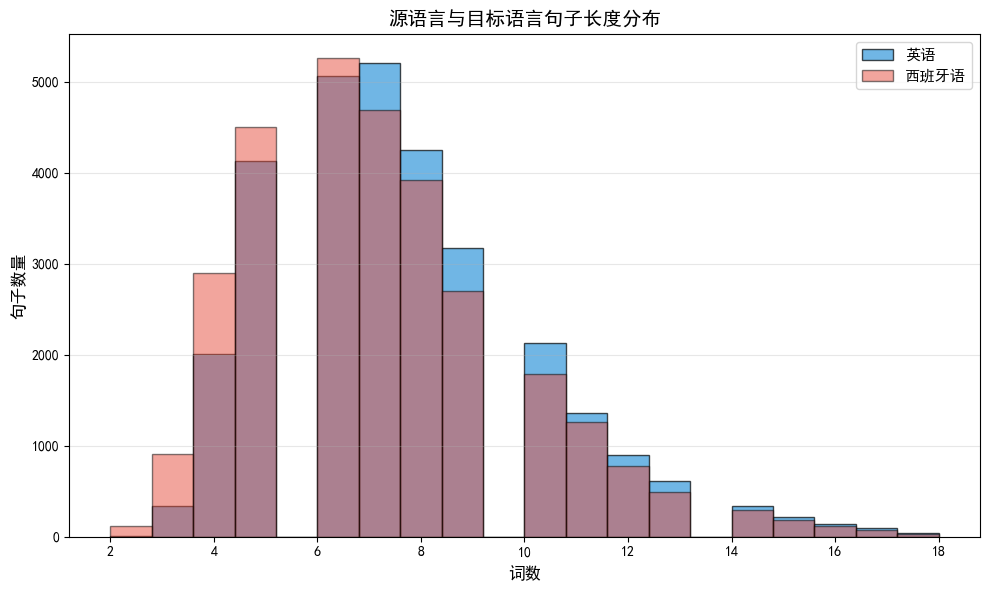

图1已保存: eda_sentence_length_distribution.png


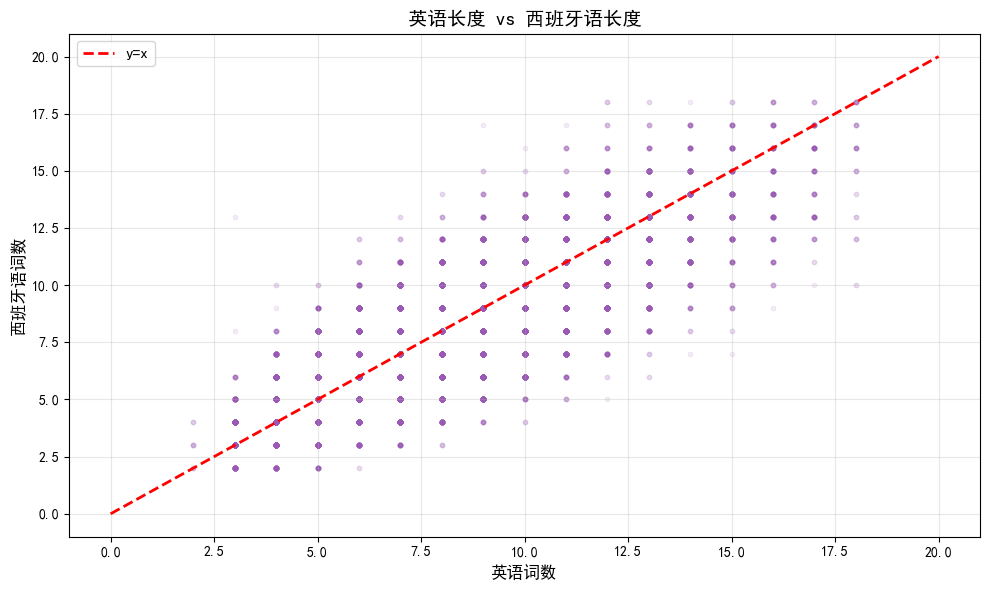

图2已保存: eda_length_correlation.png

英语句子平均长度: 7.5 词
西班牙语句子平均长度: 7.2 词

EDA 图表已保存:
  1. eda_sentence_length_distribution.png - 句子长度分布
  2. eda_length_correlation.png - 长度相关性散点图

BLEU评估函数定义完成（corpus BLEU + smoothing）。


In [29]:
# ============================================================================
# 第4部分：EDA 与 BLEU评价指标
# ============================================================================

# --- 4.1 句子长度分布 ---
eng_lengths = [len(eng.split()) for eng, _ in filtered_pairs]
spa_lengths = [len(spa.split()) for _, spa in filtered_pairs]

# 图1: 句子长度分布直方图
fig1, ax1 = plt.subplots(figsize=(10, 6))
ax1.hist(eng_lengths, bins=20, color='#3498db', alpha=0.7, edgecolor='black', label='英语')
ax1.hist(spa_lengths, bins=20, color='#e74c3c', alpha=0.5, edgecolor='black', label='西班牙语')
ax1.set_title('源语言与目标语言句子长度分布', fontsize=14, fontweight='bold')
ax1.set_xlabel('词数', fontsize=12)
ax1.set_ylabel('句子数量', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('eda_sentence_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("图1已保存: eda_sentence_length_distribution.png")

# 图2: 英语 vs 西班牙语长度散点图
fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.scatter(eng_lengths, spa_lengths, alpha=0.1, s=10, color='#9b59b6')
ax2.plot([0, 20], [0, 20], 'r--', linewidth=2, label='y=x')
ax2.set_title('英语长度 vs 西班牙语长度', fontsize=14, fontweight='bold')
ax2.set_xlabel('英语词数', fontsize=12)
ax2.set_ylabel('西班牙语词数', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('eda_length_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("图2已保存: eda_length_correlation.png")

print()
print(f"英语句子平均长度: {np.mean(eng_lengths):.1f} 词")
print(f"西班牙语句子平均长度: {np.mean(spa_lengths):.1f} 词")

print()
print("=" * 50)
print("EDA 图表已保存:")
print("  1. eda_sentence_length_distribution.png - 句子长度分布")
print("  2. eda_length_correlation.png - 长度相关性散点图")
print("=" * 50)


# --- 4.2 标准 corpus BLEU（带平滑） ---
def _ids_to_bleu_tokens(ids):
    """将token id序列转为BLEU可用的token字符串序列"""
    if isinstance(ids, np.ndarray):
        ids = ids.tolist()
    return [str(int(tok)) for tok in ids]


def compute_bleu_scores(references, hypotheses, use_smoothing=True):
    """
    计算 corpus-level BLEU-1 / BLEU-2 / BLEU-4。

    参数:
        references: List[List[int]]，每条样本的参考翻译token id序列
        hypotheses: List[List[int]]，每条样本的模型翻译token id序列
        use_smoothing: 是否使用平滑，缓解高阶n-gram稀疏导致大量0分

    返回:
        dict: {'bleu1': float, 'bleu2': float, 'bleu4': float}
    """
    if len(references) == 0 or len(hypotheses) == 0:
        return {'bleu1': 0.0, 'bleu2': 0.0, 'bleu4': 0.0}

    refs_nltk = [[_ids_to_bleu_tokens(ref)] for ref in references]
    hyps_nltk = [_ids_to_bleu_tokens(hyp) for hyp in hypotheses]

    smoother = SmoothingFunction().method1 if use_smoothing else None

    bleu1 = nltk_corpus_bleu(
        refs_nltk, hyps_nltk,
        weights=(1.0, 0.0, 0.0, 0.0),
        smoothing_function=smoother
    )
    bleu2 = nltk_corpus_bleu(
        refs_nltk, hyps_nltk,
        weights=(0.5, 0.5, 0.0, 0.0),
        smoothing_function=smoother
    )
    bleu4 = nltk_corpus_bleu(
        refs_nltk, hyps_nltk,
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smoother
    )

    return {'bleu1': bleu1, 'bleu2': bleu2, 'bleu4': bleu4}


print()
print("BLEU评估函数定义完成（corpus BLEU + smoothing）。")

## 第5部分：模型1 - Seq2Seq + Attention (GRU)

### 编码器-解码器架构
- **编码器 (Encoder)**: 将源语言句子编码为上下文向量
- **解码器 (Decoder)**: 根据上下文向量逐词生成目标语言翻译
- **注意力机制 (Bahdanau Attention)**: 解码每个词时，动态关注源句子的不同部分

### Teacher Forcing
训练时以一定概率使用真实标签（而非模型预测）作为解码器下一步的输入，加速收敛。

### 网络结构
```
Encoder: 英语句子 → Embedding → GRU → 编码器隐状态序列
Attention: 解码器隐状态 × 编码器隐状态序列 → 注意力权重 → 上下文向量
Decoder: <sos> → Embedding → GRU(上下文向量) → FC → 逐词生成西班牙语
```

In [14]:
# ============================================================================
# 第5部分：Seq2Seq + Attention 模型定义
# ============================================================================

class Encoder(nn.Module):
    """
    GRU编码器：将源语言句子编码为隐状态序列
    
    输入: 源语言词索引序列 (batch, src_len)
    输出: 
        outputs: 每个时间步的隐状态 (batch, src_len, hidden_dim)  → 供注意力机制使用
        hidden:  最后时间步的隐状态 (1, batch, hidden_dim)        → 初始化解码器
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
    
    def forward(self, x):
        embedded = self.embedding(x)           # (batch, src_len, embed_dim)
        outputs, hidden = self.gru(embedded)   # outputs: (batch, src_len, hidden)
        return outputs, hidden


class BahdanauAttention(nn.Module):
    """
    Bahdanau注意力机制（加性注意力）
    
    核心思想: 解码每个目标词时，不是只看编码器的最终隐状态，
    而是动态计算对源句子每个位置的"关注程度"（注意力权重），
    然后加权求和得到上下文向量。
    
    公式:
        score(s_t, h_i) = V^T × tanh(W1 × s_t + W2 × h_i)
        α_i = softmax(score_i)
        context = Σ α_i × h_i
    
    其中:
        s_t: 解码器当前隐状态
        h_i: 编码器第i个位置的隐状态
        α_i: 第i个位置的注意力权重
    """
    def __init__(self, hidden_dim):
        super().__init__()
        self.W1 = nn.Linear(hidden_dim, hidden_dim)  # 处理解码器隐状态
        self.W2 = nn.Linear(hidden_dim, hidden_dim)  # 处理编码器输出
        self.V  = nn.Linear(hidden_dim, 1)            # 输出注意力分数
    
    def forward(self, decoder_hidden, encoder_outputs):
        """
        参数:
            decoder_hidden:  (batch, 1, hidden)  解码器当前隐状态
            encoder_outputs: (batch, src_len, hidden)  编码器所有隐状态
        
        返回:
            context: (batch, 1, hidden)  上下文向量
            attn_weights: (batch, src_len)  注意力权重（可用于可视化）
        """
        # 计算注意力分数
        score = self.V(torch.tanh(
            self.W1(decoder_hidden) + self.W2(encoder_outputs)
        ))  # (batch, src_len, 1)
        
        attn_weights = F.softmax(score.squeeze(2), dim=1)  # (batch, src_len)
        
        # 加权求和得到上下文向量
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs)  # (batch, 1, hidden)
        
        return context, attn_weights


class Decoder(nn.Module):
    """
    GRU解码器 + 注意力机制：逐词生成目标语言翻译
    
    每个时间步:
        1. 将当前输入词嵌入
        2. 用注意力机制计算上下文向量
        3. 将嵌入和上下文向量拼接，输入GRU
        4. 通过全连接层预测下一个词
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.attention = BahdanauAttention(hidden_dim)
        # GRU输入 = 词嵌入 + 上下文向量
        self.gru = nn.GRU(embed_dim + hidden_dim, hidden_dim, batch_first=True)
        # 输出层: 预测目标词表中每个词的概率
        self.fc = nn.Linear(hidden_dim, vocab_size)
    
    def forward(self, x, hidden, encoder_outputs):
        """
        解码一个时间步
        
        参数:
            x: (batch,) 当前输入词索引
            hidden: (1, batch, hidden) 解码器隐状态
            encoder_outputs: (batch, src_len, hidden) 编码器输出
        
        返回:
            output: (batch, vocab_size) 下一个词的概率分布
            hidden: (1, batch, hidden) 更新后的隐状态
            attn_weights: (batch, src_len) 注意力权重
        """
        embedded = self.embedding(x).unsqueeze(1)  # (batch, 1, embed)
        
        # 注意力: 用当前隐状态查询编码器输出
        context, attn_weights = self.attention(
            hidden.permute(1, 0, 2),  # (batch, 1, hidden)
            encoder_outputs
        )
        
        # 拼接嵌入和上下文向量
        gru_input = torch.cat([embedded, context], dim=2)  # (batch, 1, embed+hidden)
        
        output, hidden = self.gru(gru_input, hidden)
        output = self.fc(output.squeeze(1))  # (batch, vocab_size)
        
        return output, hidden, attn_weights


class Seq2Seq(nn.Module):
    """
    完整的Seq2Seq模型：编码器 + 解码器 + 注意力
    """
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
    
    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        """
        参数:
            src: (batch, src_len) 源语言序列
            trg: (batch, trg_len) 目标语言序列
            teacher_forcing_ratio: Teacher Forcing概率
        
        返回:
            outputs: (batch, trg_len, vocab_size) 每个位置的预测概率
        """
        batch_size = src.size(0)
        trg_len = trg.size(1)
        trg_vocab_size = self.decoder.fc.out_features
        
        # 存储每个时间步的输出
        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size).to(DEVICE)
        
        # 编码
        encoder_outputs, hidden = self.encoder(src)
        
        # 解码器第一个输入是<sos>
        decoder_input = trg[:, 0]  # (batch,) 全是SOS_IDX
        
        for t in range(1, trg_len):
            output, hidden, _ = self.decoder(decoder_input, hidden, encoder_outputs)
            outputs[:, t, :] = output
            
            # Teacher Forcing: 以一定概率使用真实标签作为下一步输入
            use_teacher_forcing = random.random() < teacher_forcing_ratio
            if use_teacher_forcing:
                decoder_input = trg[:, t]  # 使用真实标签
            else:
                decoder_input = output.argmax(dim=1)  # 使用模型预测
        
        return outputs


# --- 初始化模型 ---
encoder = Encoder(eng_vocab.n_words, EMBEDDING_DIM, HIDDEN_DIM)
decoder = Decoder(spa_vocab.n_words, EMBEDDING_DIM, HIDDEN_DIM)
model_seq2seq = Seq2Seq(encoder, decoder).to(DEVICE)

print(f"Seq2Seq+Attention 参数量: {sum(p.numel() for p in model_seq2seq.parameters()):,}")
print(f"  编码器: {sum(p.numel() for p in encoder.parameters()):,}")
print(f"  解码器: {sum(p.numel() for p in decoder.parameters()):,}")

Seq2Seq+Attention 参数量: 10,167,453
  编码器: 2,403,840
  解码器: 7,763,613


In [15]:
# --- 5.2 训练与评估Seq2Seq ---
criterion_s2s = nn.CrossEntropyLoss(ignore_index=PAD_IDX)  # 忽略<pad>位置的损失
optimizer_s2s = optim.Adam(model_seq2seq.parameters(), lr=LEARNING_RATE)

def train_seq2seq_epoch(model, loader, criterion, optimizer):
    """训练Seq2Seq一个epoch"""
    model.train()
    total_loss = 0
    for src, trg in loader:
        src, trg = src.to(DEVICE), trg.to(DEVICE)
        optimizer.zero_grad()

        # 前向传播
        output = model(src, trg, TEACHER_FORCING_RATIO)
        # output: (batch, trg_len, vocab_size)
        # 需要reshape为 (batch*trg_len, vocab_size) 来计算CrossEntropyLoss
        output = output[:, 1:, :].reshape(-1, output.size(-1))  # 去掉第一个时间步（<sos>）
        trg = trg[:, 1:].reshape(-1)  # 对应的真实标签

        loss = criterion(output, trg)
        loss.backward()
        # 梯度裁剪: 防止RNN中的梯度爆炸
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def translate_sentence_greedy(model, src_tensor, max_len=MAX_SEQ_LEN):
    """Greedy解码：每一步都选最大概率token"""
    model.eval()
    with torch.no_grad():
        src = src_tensor.unsqueeze(0).to(DEVICE)  # (1, src_len)
        encoder_outputs, hidden = model.encoder(src)

        decoder_input = torch.tensor([SOS_IDX], device=DEVICE)
        translated_ids = []

        for _ in range(max_len):
            output, hidden, _ = model.decoder(decoder_input, hidden, encoder_outputs)
            predicted_id = output.argmax(dim=1).item()

            if predicted_id == EOS_IDX:
                break
            translated_ids.append(predicted_id)
            decoder_input = torch.tensor([predicted_id], device=DEVICE)

    return translated_ids


def translate_sentence_beam(model, src_tensor, beam_size=BEAM_SIZE,
                            length_penalty=LENGTH_PENALTY, max_len=MAX_SEQ_LEN):
    """
    Beam Search解码（batch=1）。

    评分函数:
        score = log_prob / (length ** length_penalty)
    """
    model.eval()
    with torch.no_grad():
        src = src_tensor.unsqueeze(0).to(DEVICE)
        encoder_outputs, hidden = model.encoder(src)

        # beam元素: (token_ids, hidden_state, cumulative_log_prob, finished)
        beams = [([SOS_IDX], hidden, 0.0, False)]

        for _ in range(max_len):
            candidates = []

            for token_ids, h, cum_log_prob, finished in beams:
                if finished:
                    candidates.append((token_ids, h, cum_log_prob, True))
                    continue

                decoder_input = torch.tensor([token_ids[-1]], device=DEVICE)
                output, next_hidden, _ = model.decoder(decoder_input, h, encoder_outputs)

                log_probs = F.log_softmax(output, dim=1).squeeze(0)  # (vocab_size,)
                topk_log_probs, topk_ids = torch.topk(log_probs, k=beam_size)

                for lp, idx in zip(topk_log_probs.tolist(), topk_ids.tolist()):
                    new_ids = token_ids + [idx]
                    new_finished = (idx == EOS_IDX)
                    candidates.append((new_ids, next_hidden.clone(), cum_log_prob + lp, new_finished))

            def beam_score(item):
                token_ids, _, cum_log_prob, _ = item
                length = max(len(token_ids) - 1, 1)  # 不把<sos>算进长度
                return cum_log_prob / (length ** length_penalty)

            beams = sorted(candidates, key=beam_score, reverse=True)[:beam_size]

            # 全部beam都已结束，提前停止
            if all(finished for _, _, _, finished in beams):
                break

        best_ids = beams[0][0]  # 最高分beam

        # 去掉<sos>并在<eos>处截断
        translated_ids = []
        for idx in best_ids[1:]:
            if idx == EOS_IDX:
                break
            translated_ids.append(idx)

        return translated_ids


def evaluate_bleu(model, test_data_eng, test_data_spa, decode_method='beam'):
    """在测试集上计算BLEU-1/2/4"""
    references = []
    hypotheses = []

    for i in range(len(test_data_eng)):
        src_tensor = torch.tensor(test_data_eng[i], dtype=torch.long)

        if decode_method == 'beam':
            translated_ids = translate_sentence_beam(model, src_tensor)
        else:
            translated_ids = translate_sentence_greedy(model, src_tensor)

        # 参考翻译: 去掉<sos>, <eos>, <pad>
        ref_ids = [idx for idx in test_data_spa[i] if idx not in (PAD_IDX, SOS_IDX, EOS_IDX)]

        references.append(ref_ids)
        hypotheses.append(translated_ids)

    return compute_bleu_scores(references, hypotheses, use_smoothing=True)


# --- 训练循环 ---
history_s2s = {'train_loss': [], 'bleu1': [], 'bleu2': [], 'bleu4': []}

print()
print('=' * 50)
print('开始训练 Seq2Seq + Attention')
print('=' * 50)

for epoch in range(EPOCHS_SEQ2SEQ):
    t0 = time.time()
    train_loss = train_seq2seq_epoch(model_seq2seq, train_loader, criterion_s2s, optimizer_s2s)

    should_eval = ((epoch + 1) % BLEU_EVAL_EVERY == 0) or (epoch == 0)
    if should_eval:
        bleu_scores = evaluate_bleu(model_seq2seq, eng_test, spa_test, decode_method='beam')
        b1, b2, b4 = bleu_scores['bleu1'], bleu_scores['bleu2'], bleu_scores['bleu4']
        history_s2s['bleu1'].append(b1)
        history_s2s['bleu2'].append(b2)
        history_s2s['bleu4'].append(b4)
        bleu_msg = f'BLEU-1: {b1:.4f} - BLEU-2: {b2:.4f} - BLEU-4: {b4:.4f}'
    else:
        history_s2s['bleu1'].append(np.nan)
        history_s2s['bleu2'].append(np.nan)
        history_s2s['bleu4'].append(np.nan)
        bleu_msg = 'BLEU: N/A'

    elapsed = time.time() - t0
    history_s2s['train_loss'].append(train_loss)

    print(f'Epoch {epoch+1}/{EPOCHS_SEQ2SEQ} - Loss: {train_loss:.4f} - {bleu_msg} - 耗时: {elapsed:.1f}s')

# 最终BLEU（使用Beam Search）
final_s2s = evaluate_bleu(model_seq2seq, eng_test, spa_test, decode_method='beam')
s2s_bleu1 = final_s2s['bleu1']
s2s_bleu2 = final_s2s['bleu2']
s2s_bleu4 = final_s2s['bleu4']
s2s_bleu = s2s_bleu4  # 兼容后续代码中的变量名

print()
print(f'Seq2Seq+Attention 最终BLEU-1: {s2s_bleu1:.4f}')
print(f'Seq2Seq+Attention 最终BLEU-2: {s2s_bleu2:.4f}')
print(f'Seq2Seq+Attention 最终BLEU-4: {s2s_bleu4:.4f}')
if torch.cuda.is_available():
    torch.cuda.empty_cache()


开始训练 Seq2Seq + Attention
Epoch 1/20 - Loss: 5.1989 - BLEU-1: 0.3308 - BLEU-2: 0.1219 - BLEU-4: 0.0184 - 耗时: 117.0s
Epoch 2/20 - Loss: 4.0236 - BLEU: N/A - 耗时: 27.1s
Epoch 3/20 - Loss: 3.2875 - BLEU: N/A - 耗时: 27.1s
Epoch 4/20 - Loss: 2.7352 - BLEU: N/A - 耗时: 27.1s
Epoch 5/20 - Loss: 2.2899 - BLEU-1: 0.5837 - BLEU-2: 0.4137 - BLEU-4: 0.2198 - 耗时: 106.5s
Epoch 6/20 - Loss: 1.9306 - BLEU: N/A - 耗时: 27.4s
Epoch 7/20 - Loss: 1.6238 - BLEU: N/A - 耗时: 29.3s
Epoch 8/20 - Loss: 1.3487 - BLEU: N/A - 耗时: 29.9s
Epoch 9/20 - Loss: 1.1481 - BLEU: N/A - 耗时: 29.4s
Epoch 10/20 - Loss: 0.9895 - BLEU-1: 0.6261 - BLEU-2: 0.4682 - BLEU-4: 0.2761 - 耗时: 116.4s
Epoch 11/20 - Loss: 0.8460 - BLEU: N/A - 耗时: 27.8s
Epoch 12/20 - Loss: 0.7454 - BLEU: N/A - 耗时: 34.5s
Epoch 13/20 - Loss: 0.6458 - BLEU: N/A - 耗时: 38.7s
Epoch 14/20 - Loss: 0.5649 - BLEU: N/A - 耗时: 39.8s
Epoch 15/20 - Loss: 0.5053 - BLEU-1: 0.6205 - BLEU-2: 0.4642 - BLEU-4: 0.2743 - 耗时: 144.9s
Epoch 16/20 - Loss: 0.4356 - BLEU: N/A - 耗时: 28.3s
Epoch 1

In [16]:
# --- 5.3 Seq2Seq 翻译示例展示 ---
print("=" * 60)
print("Seq2Seq + Attention 翻译示例（Beam Search）")
print("=" * 60)

# 随机选取10条测试集句子展示翻译效果
sample_indices = random.sample(range(len(eng_test)), 10)

for idx in sample_indices:
    src_tensor = torch.tensor(eng_test[idx], dtype=torch.long)
    translated_ids_beam = translate_sentence_beam(model_seq2seq, src_tensor)

    # 还原文本
    src_text = eng_vocab.decode_sequence(eng_test[idx])
    ref_text = spa_vocab.decode_sequence(spa_test[idx])
    hyp_text_beam = spa_vocab.decode_sequence(translated_ids_beam)

    print(f"  英语原文:   {src_text}")
    print(f"  参考翻译:   {ref_text}")
    print(f"  Beam翻译:   {hyp_text_beam}")
    print()


Seq2Seq + Attention 翻译示例（Beam Search）
  英语原文:   i had a dreadful dream last night .
  参考翻译:   he tenido un sueño espantoso esta noche .
  Beam翻译:   anoche comí un dolor de anoche .

  英语原文:   that was my finger .
  参考翻译:   ese era mi dedo .
  Beam翻译:   ese fue mi dedo .

  英语原文:   call tom .
  参考翻译:   ¡ llámalo a tomás !
  Beam翻译:   llama a tom .

  英语原文:   is that you ?
  参考翻译:   ¿ es usted ?
  Beam翻译:   ¿ eres tú ?

  英语原文:   this is holy ground .
  参考翻译:   este lugar es sagrado .
  Beam翻译:   esto es un país .

  英语原文:   tell me something i don t already know .
  参考翻译:   contame algo que todavía no sepa .
  Beam翻译:   dime algo que yo ya sé .

  英语原文:   where can i pick up my airplane ticket ?
  参考翻译:   ¿ dónde puedo coger mi pasaje de avión ?
  Beam翻译:   ¿ dónde puedo pasar mi vida ?

  英语原文:   hold on one second .
  参考翻译:   espera un segundo .
  Beam翻译:   aguarda un segundo segundo .

  英语原文:   you aren t stupid .
  参考翻译:   no eres estúpido .
  Beam翻译:   no sos estúpida .

  英语原文:  

## 第6部分：模型2 - Transformer 翻译模型

### 与分类任务Transformer的区别
- 分类任务只用 Encoder，翻译任务需要 Encoder + Decoder
- Decoder中有两种注意力：
  - **自注意力 (Self-Attention)**: 目标序列内部的注意力
  - **交叉注意力 (Cross-Attention)**: 目标序列对源序列的注意力
- Decoder使用因果掩码 (Causal Mask)，防止"偷看"未来的词

### 网络结构
```
Encoder: 英语 → Embedding + PosEnc → N × EncoderLayer → memory
Decoder: 西班牙语 → Embedding + PosEnc → N × DecoderLayer(self-attn + cross-attn) → FC → 词概率
```

In [17]:
# ============================================================================
# 第6部分：Transformer 翻译模型
# ============================================================================

class PositionalEncoding(nn.Module):
    """位置编码（与分类任务中相同）"""
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class TransformerTranslator(nn.Module):
    """
    基于Transformer的机器翻译模型（完整Encoder-Decoder架构）
    
    与分类任务Transformer的关键区别:
        1. 使用完整的Encoder-Decoder结构（分类只用Encoder）
        2. Decoder有因果掩码（Causal Mask），防止看到未来的词
        3. Decoder有交叉注意力（Cross-Attention），关注源语言
    
    参数:
        src_vocab_size: 源语言词表大小
        trg_vocab_size: 目标语言词表大小
        d_model:        模型维度
        nhead:          多头注意力头数
        num_layers:     编码器/解码器层数
        dim_ff:         前馈网络维度
    """
    def __init__(self, src_vocab_size, trg_vocab_size, d_model=HIDDEN_DIM,
                 nhead=NUM_HEADS, num_layers=NUM_LAYERS, dim_ff=FF_DIM):
        super().__init__()
        
        # 源语言和目标语言各自的Embedding
        self.src_embedding = nn.Embedding(src_vocab_size, d_model, padding_idx=PAD_IDX)
        self.trg_embedding = nn.Embedding(trg_vocab_size, d_model, padding_idx=PAD_IDX)
        self.pos_encoder = PositionalEncoding(d_model)
        
        # PyTorch内置的Transformer模块
        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_layers,
            num_decoder_layers=num_layers,
            dim_feedforward=dim_ff,
            dropout=0.1,
            batch_first=True
        )
        
        # 输出层: 将Transformer输出映射到目标词表大小
        self.fc_out = nn.Linear(d_model, trg_vocab_size)
        self.d_model = d_model
    
    def forward(self, src, trg):
        """
        参数:
            src: (batch, src_len) 源语言序列
            trg: (batch, trg_len) 目标语言序列（训练时使用Teacher Forcing）
        """
        # --- 生成掩码 ---
        # 因果掩码: 上三角矩阵，防止Decoder看到未来的词
        trg_len = trg.size(1)
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(trg_len).to(DEVICE)
        
        # Padding掩码: 告诉模型哪些位置是padding
        src_pad_mask = (src == PAD_IDX)  # (batch, src_len)
        trg_pad_mask = (trg == PAD_IDX)  # (batch, trg_len)
        
        # --- Embedding + 位置编码 ---
        src_emb = self.pos_encoder(self.src_embedding(src) * math.sqrt(self.d_model))
        trg_emb = self.pos_encoder(self.trg_embedding(trg) * math.sqrt(self.d_model))
        
        # --- Transformer前向传播 ---
        output = self.transformer(
            src_emb, trg_emb,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_pad_mask,
            tgt_key_padding_mask=trg_pad_mask,
            memory_key_padding_mask=src_pad_mask
        )
        
        return self.fc_out(output)  # (batch, trg_len, trg_vocab_size)


# --- 初始化 ---
model_tf = TransformerTranslator(eng_vocab.n_words, spa_vocab.n_words).to(DEVICE)
print(f"Transformer翻译模型 参数量: {sum(p.numel() for p in model_tf.parameters()):,}")

Transformer翻译模型 参数量: 11,686,300


In [18]:
# ============================================================================
# 第6部分（全面优化版）：Transformer 训练与评估
# ============================================================================

import sys

# --- 6.2.1 优化的学习率调度器 ---
class WarmupScheduler:
    """
    优化的学习率调度器
    - 前 warmup_steps 步线性增加
    - 之后保持恒定
    """
    def __init__(self, optimizer, warmup_steps=4000, max_lr=0.001):
        self.optimizer = optimizer
        self.warmup_steps = warmup_steps
        self.max_lr = max_lr
        self.step_num = 0
        
    def step(self):
        self.step_num += 1
        lr = self._get_lr()
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = lr
    
    def _get_lr(self):
        if self.step_num < self.warmup_steps:
            return self.max_lr * (self.step_num / self.warmup_steps)
        else:
            return self.max_lr


# --- 6.2.2 Transformer Beam Search 解码（优化版）---
def translate_sentence_tf_beam(model, src_tensor, beam_size=BEAM_SIZE,
                                length_penalty=LENGTH_PENALTY, max_len=MAX_SEQ_LEN):
    """Transformer Beam Search 解码"""
    model.eval()
    with torch.no_grad():
        src = src_tensor.unsqueeze(0).to(DEVICE)
        beams = [([SOS_IDX], 0.0, False)]
        
        for _ in range(max_len):
            candidates = []
            
            for token_ids, cum_log_prob, finished in beams:
                if finished:
                    candidates.append((token_ids, cum_log_prob, True))
                    continue
                
                trg_tensor = torch.tensor([token_ids], dtype=torch.long).to(DEVICE)
                output = model(src, trg_tensor)
                log_probs = F.log_softmax(output[0, -1, :], dim=0)
                topk_log_probs, topk_ids = torch.topk(log_probs, k=beam_size)
                
                for lp, idx in zip(topk_log_probs.tolist(), topk_ids.tolist()):
                    new_ids = token_ids + [idx]
                    new_finished = (idx == EOS_IDX)
                    candidates.append((new_ids, cum_log_prob + lp, new_finished))
            
            def beam_score(item):
                token_ids, cum_log_prob, _ = item
                length = max(len(token_ids) - 1, 1)
                return cum_log_prob / (length ** length_penalty)
            
            beams = sorted(candidates, key=beam_score, reverse=True)[:beam_size]
            
            if all(finished for _, _, finished in beams):
                break
        
        best_ids = beams[0][0]
        translated_ids = []
        for idx in best_ids[1:]:
            if idx == EOS_IDX:
                break
            translated_ids.append(idx)
        
        return translated_ids


# --- 6.2.3 训练与评估函数 ---
criterion_tf = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer_tf = optim.Adam(model_tf.parameters(), lr=0.001, betas=(0.9, 0.98), eps=1e-9)
scheduler_tf = WarmupScheduler(optimizer_tf, warmup_steps=4000, max_lr=0.001)

def train_transformer_epoch(model, loader, criterion, optimizer, scheduler):
    """训练 Transformer 一个 epoch"""
    model.train()
    total_loss = 0
    for src, trg in loader:
        src, trg = src.to(DEVICE), trg.to(DEVICE)
        optimizer.zero_grad()
        
        trg_input = trg[:, :-1]
        trg_target = trg[:, 1:]
        
        output = model(src, trg_input)
        output = output.reshape(-1, output.size(-1))
        trg_target = trg_target.reshape(-1)
        
        loss = criterion(output, trg_target)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def translate_sentence_tf_greedy(model, src_tensor, max_len=MAX_SEQ_LEN):
    """Transformer 贪心解码"""
    model.eval()
    with torch.no_grad():
        src = src_tensor.unsqueeze(0).to(DEVICE)
        trg_ids = [SOS_IDX]
        
        for _ in range(max_len):
            trg_tensor = torch.tensor([trg_ids], dtype=torch.long).to(DEVICE)
            output = model(src, trg_tensor)
            next_token = output[0, -1, :].argmax().item()
            
            if next_token == EOS_IDX:
                break
            trg_ids.append(next_token)
        
        return trg_ids[1:]


def evaluate_bleu_tf(model, test_data_eng, test_data_spa, decode_method='beam', sample_size=None):
    """
    在测试集上计算 Transformer 的 BLEU-1/2/4
    
    参数:
        sample_size: None 表示使用全部数据，否则随机采样指定数量
    """
    references = []
    hypotheses = []
    
    if sample_size is not None and sample_size < len(test_data_eng):
        indices = random.sample(range(len(test_data_eng)), sample_size)
    else:
        indices = range(len(test_data_eng))
    
    for i in indices:
        src_tensor = torch.tensor(test_data_eng[i], dtype=torch.long)
        
        if decode_method == 'beam':
            translated_ids = translate_sentence_tf_beam(model, src_tensor)
        else:
            translated_ids = translate_sentence_tf_greedy(model, src_tensor)
        
        ref_ids = [idx for idx in test_data_spa[i] if idx not in (PAD_IDX, SOS_IDX, EOS_IDX)]
        references.append(ref_ids)
        hypotheses.append(translated_ids)
    
    return compute_bleu_scores(references, hypotheses, use_smoothing=True)


# --- 6.2.4 训练循环 ---
history_tf = {'train_loss': [], 'bleu1': [], 'bleu2': [], 'bleu4': []}

print()
print('=' * 50)
print('开始训练 Transformer（优化版）')
print('=' * 50)
print('优化策略：')
print('  1. 修复学习率调度器')
print('  2. 训练时快速评估（500样本），最终完整评估（3000样本）')
print('  3. 使用 Beam Search 提升翻译质量')
sys.stdout.flush()

for epoch in range(EPOCHS_TF):
    t0 = time.time()
    
    print(f'Epoch {epoch+1}/{EPOCHS_TF} - 训练中...', end='', flush=True)
    train_loss = train_transformer_epoch(model_tf, train_loader, criterion_tf, optimizer_tf, scheduler_tf)
    print(f' Loss: {train_loss:.4f}', end='', flush=True)
    
    # 每 5 个 epoch 或第 1 个 epoch 评估（使用 500 样本快速评估）
    should_eval = ((epoch + 1) % BLEU_EVAL_EVERY == 0) or (epoch == 0)
    if should_eval:
        print(' - 评估中...', end='', flush=True)
        bleu_scores = evaluate_bleu_tf(model_tf, eng_test, spa_test, decode_method='beam', sample_size=500)
        b1, b2, b4 = bleu_scores['bleu1'], bleu_scores['bleu2'], bleu_scores['bleu4']
        history_tf['bleu1'].append(b1)
        history_tf['bleu2'].append(b2)
        history_tf['bleu4'].append(b4)
        bleu_msg = f' BLEU-1: {b1:.4f} - BLEU-2: {b2:.4f} - BLEU-4: {b4:.4f}'
    else:
        history_tf['bleu1'].append(np.nan)
        history_tf['bleu2'].append(np.nan)
        history_tf['bleu4'].append(np.nan)
        bleu_msg = ' BLEU: N/A'
    
    elapsed = time.time() - t0
    history_tf['train_loss'].append(train_loss)
    
    current_lr = optimizer_tf.param_groups[0]['lr']
    print(f' - LR: {current_lr:.6f} -{bleu_msg} - 耗时: {elapsed:.1f}s')
    sys.stdout.flush()

# --- 最终完整评估（使用全部 3000 个测试样本）---
print()
print('=' * 50)
print('最终评估（全部 3000 个测试样本，Beam Search）')
print('=' * 50)
sys.stdout.flush()

tf_final = evaluate_bleu_tf(model_tf, eng_test, spa_test, decode_method='beam', sample_size=None)
tf_bleu1 = tf_final['bleu1']
tf_bleu2 = tf_final['bleu2']
tf_bleu4 = tf_final['bleu4']
tf_bleu = tf_bleu4  # 兼容后续代码

print(f'Transformer (Beam Search) - BLEU-1: {tf_bleu1:.4f}')
print(f'Transformer (Beam Search) - BLEU-2: {tf_bleu2:.4f}')
print(f'Transformer (Beam Search) - BLEU-4: {tf_bleu4:.4f}')

# --- Greedy vs Beam Search 对比 ---
print()
print('=' * 50)
print('解码策略对比（全部 3000 个测试样本）')
print('=' * 50)
sys.stdout.flush()

greedy_scores = evaluate_bleu_tf(model_tf, eng_test, spa_test, decode_method='greedy', sample_size=None)
print(f'Greedy 解码  - BLEU-1: {greedy_scores["bleu1"]:.4f} - BLEU-2: {greedy_scores["bleu2"]:.4f} - BLEU-4: {greedy_scores["bleu4"]:.4f}')
print(f'Beam Search  - BLEU-1: {tf_bleu1:.4f} - BLEU-2: {tf_bleu2:.4f} - BLEU-4: {tf_bleu4:.4f}')
print(f'提升幅度     - BLEU-1: +{(tf_bleu1 - greedy_scores["bleu1"]):.4f} - BLEU-2: +{(tf_bleu2 - greedy_scores["bleu2"]):.4f} - BLEU-4: +{(tf_bleu4 - greedy_scores["bleu4"]):.4f}')

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print()
print('Transformer 训练完成！')
sys.stdout.flush()


开始训练 Transformer（优化版）
优化策略：
  1. 修复学习率调度器
  2. 训练时快速评估（500样本），最终完整评估（3000样本）
  3. 使用 Beam Search 提升翻译质量
Epoch 1/20 - 训练中... Loss: 6.6279 - 评估中... - LR: 0.000106 - BLEU-1: 0.2559 - BLEU-2: 0.0635 - BLEU-4: 0.0040 - 耗时: 161.4s
Epoch 2/20 - 训练中... Loss: 4.6750 - LR: 0.000211 - BLEU: N/A - 耗时: 12.9s
Epoch 3/20 - 训练中... Loss: 3.9732 - LR: 0.000316 - BLEU: N/A - 耗时: 13.5s
Epoch 4/20 - 训练中... Loss: 3.4620 - LR: 0.000422 - BLEU: N/A - 耗时: 12.1s
Epoch 5/20 - 训练中... Loss: 3.0533 - 评估中... - LR: 0.000527 - BLEU-1: 0.4571 - BLEU-2: 0.2928 - BLEU-4: 0.1363 - 耗时: 157.0s
Epoch 6/20 - 训练中... Loss: 2.7190 - LR: 0.000633 - BLEU: N/A - 耗时: 12.5s
Epoch 7/20 - 训练中... Loss: 2.4504 - LR: 0.000739 - BLEU: N/A - 耗时: 12.5s
Epoch 8/20 - 训练中... Loss: 2.2398 - LR: 0.000844 - BLEU: N/A - 耗时: 13.0s
Epoch 9/20 - 训练中... Loss: 2.0722 - LR: 0.000950 - BLEU: N/A - 耗时: 14.9s
Epoch 10/20 - 训练中... Loss: 1.9449 - 评估中... - LR: 0.001000 - BLEU-1: 0.5349 - BLEU-2: 0.3849 - BLEU-4: 0.2091 - 耗时: 125.2s
Epoch 11/20 - 训练中... Loss: 

In [20]:
# --- 6.3 Transformer 翻译示例展示 ---
print("=" * 60)
print("Transformer 翻译示例（Beam Search）")
print("=" * 60)

# 使用与 Seq2Seq 相同的样本索引，方便对比
for idx in sample_indices:
    src_tensor = torch.tensor(eng_test[idx], dtype=torch.long)
    translated_ids = translate_sentence_tf_beam(model_tf, src_tensor)
    
    src_text = eng_vocab.decode_sequence(eng_test[idx])
    ref_text = spa_vocab.decode_sequence(spa_test[idx])
    hyp_text = spa_vocab.decode_sequence(translated_ids)
    
    print(f"  英语原文:   {src_text}")
    print(f"  参考翻译:   {ref_text}")
    print(f"  模型翻译:   {hyp_text}")
    print()

Transformer 翻译示例（Beam Search）
  英语原文:   i had a dreadful dream last night .
  参考翻译:   he tenido un sueño espantoso esta noche .
  模型翻译:   tuve un sueño anoche .

  英语原文:   that was my finger .
  参考翻译:   ese era mi dedo .
  模型翻译:   ese fue mi dedo .

  英语原文:   call tom .
  参考翻译:   ¡ llámalo a tomás !
  模型翻译:   tom llame .

  英语原文:   is that you ?
  参考翻译:   ¿ es usted ?
  模型翻译:   ¿ es eso ?

  英语原文:   this is holy ground .
  参考翻译:   este lugar es sagrado .
  模型翻译:   este es un papá .

  英语原文:   tell me something i don t already know .
  参考翻译:   contame algo que todavía no sepa .
  模型翻译:   no sé algo que ya .

  英语原文:   where can i pick up my airplane ticket ?
  参考翻译:   ¿ dónde puedo coger mi pasaje de avión ?
  模型翻译:   ¿ dónde puedo comprar el avión de mi mamá ?

  英语原文:   hold on one second .
  参考翻译:   espera un segundo .
  模型翻译:   un segundo piso .

  英语原文:   you aren t stupid .
  参考翻译:   no eres estúpido .
  模型翻译:   no sos estúpida .

  英语原文:   i stared her in the face .
  参考翻译:   la 

## 第7部分：实验结果对比与可视化

对比两个翻译模型的表现：
- **训练损失曲线**: 观察收敛速度和稳定性
- **BLEU分数对比**: 翻译质量的量化指标
- **翻译示例对比**: 直观感受翻译效果差异

实验结果汇总（两个模型均使用 Beam Search）
                        模型   BLEU-1   BLEU-2   BLEU-4      参数量
Seq2Seq + Attention (Beam) 0.618203 0.460670 0.273285 10167453
        Transformer (Beam) 0.589973 0.438062 0.260715 11686300



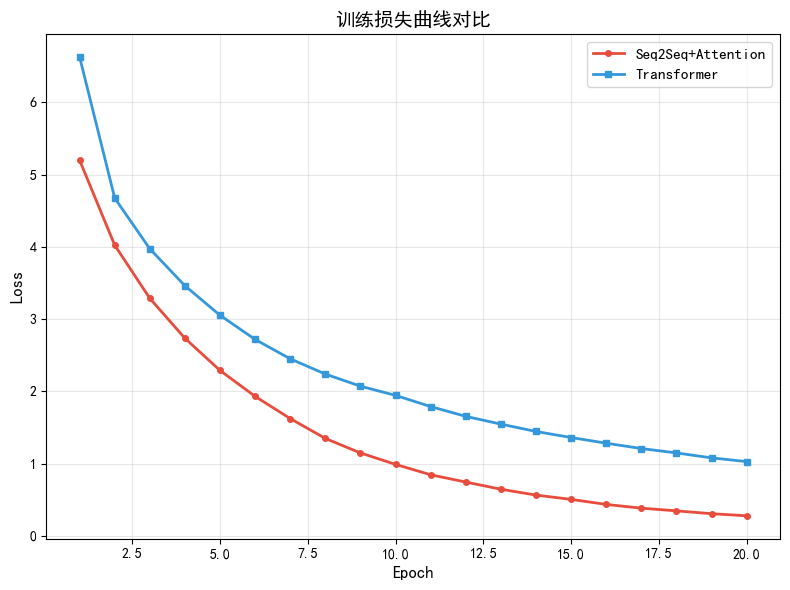

图1已保存: loss_comparison.png


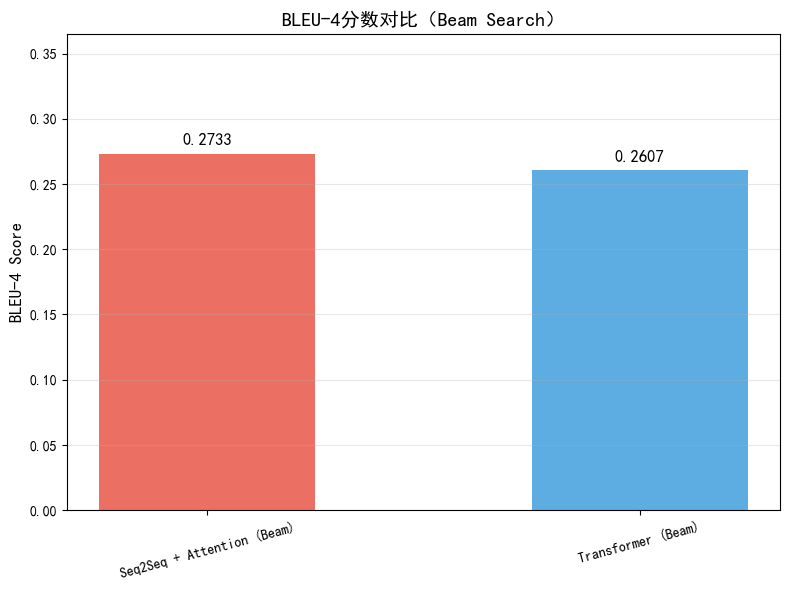

图2已保存: bleu4_comparison.png


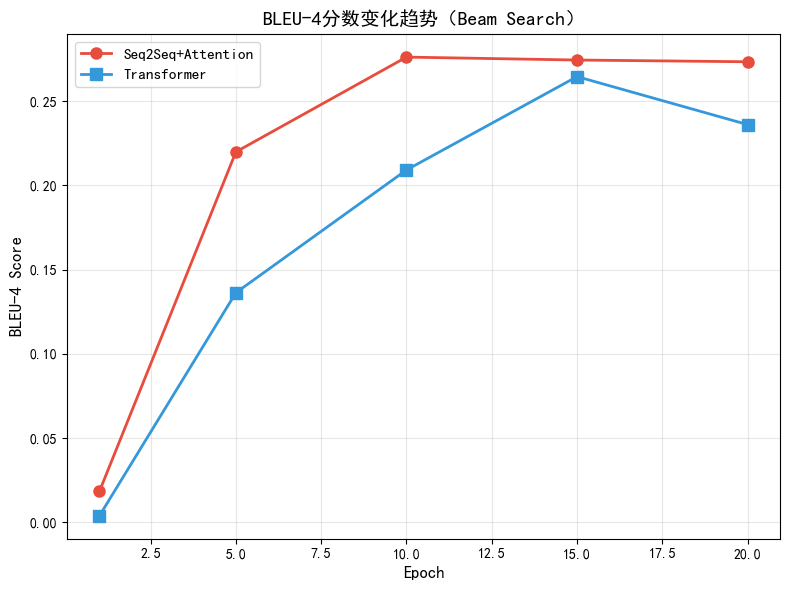

图3已保存: bleu4_trend.png

所有图表已保存:
  1. loss_comparison.png - 训练损失曲线对比
  2. bleu4_comparison.png - BLEU-4分数柱状图
  3. bleu4_trend.png - BLEU-4分数变化趋势


In [28]:
# ============================================================================
# 第7部分：实验结果对比与可视化
# ============================================================================

# --- 7.1 结果汇总表 ---
results = pd.DataFrame({
    '模型': ['Seq2Seq + Attention (Beam)', 'Transformer (Beam)'],
    'BLEU-1': [s2s_bleu1, tf_bleu1],
    'BLEU-2': [s2s_bleu2, tf_bleu2],
    'BLEU-4': [s2s_bleu4, tf_bleu4],
    '参数量': [
        sum(p.numel() for p in model_seq2seq.parameters()),
        sum(p.numel() for p in model_tf.parameters())
    ]
})
print("=" * 50)
print("实验结果汇总（两个模型均使用 Beam Search）")
print("=" * 50)
print(results.to_string(index=False))
print()

# --- 7.2 可视化（分开保存三张图）---

# 图1: 训练损失曲线对比
fig1, ax1 = plt.subplots(figsize=(8, 6))
ax1.plot(range(1, EPOCHS_SEQ2SEQ+1), history_s2s['train_loss'],
         'o-', label='Seq2Seq+Attention', color='#e74c3c', markersize=4, linewidth=2)
ax1.plot(range(1, EPOCHS_TF+1), history_tf['train_loss'],
         's-', label='Transformer', color='#3498db', markersize=4, linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('训练损失曲线对比', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("图1已保存: loss_comparison.png")

# 图2: BLEU-4分数柱状图
fig2, ax2 = plt.subplots(figsize=(8, 6))
colors = ['#e74c3c', '#3498db']
bars = ax2.bar(results['模型'], results['BLEU-4'], color=colors, width=0.5, alpha=0.8)
ax2.set_title('BLEU-4分数对比（Beam Search）', fontsize=14, fontweight='bold')
ax2.set_ylabel('BLEU-4 Score', fontsize=12)
ax2.set_ylim(0, max(results['BLEU-4']) * 1.3 + 0.01)
for bar, val in zip(bars, results['BLEU-4']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=15)
ax2.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('bleu4_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("图2已保存: bleu4_comparison.png")

# 图3: BLEU-4随训练变化趋势
fig3, ax3 = plt.subplots(figsize=(8, 6))
epoch_axis_s2s = np.arange(1, EPOCHS_SEQ2SEQ + 1)
epoch_axis_tf = np.arange(1, EPOCHS_TF + 1)
bleu4_s2s = np.array(history_s2s['bleu4'], dtype=float)
bleu4_tf = np.array(history_tf['bleu4'], dtype=float)

valid_s2s = ~np.isnan(bleu4_s2s)
valid_tf = ~np.isnan(bleu4_tf)

ax3.plot(epoch_axis_s2s[valid_s2s], bleu4_s2s[valid_s2s], 'o-',
         label='Seq2Seq+Attention', color='#e74c3c', markersize=8, linewidth=2)
ax3.plot(epoch_axis_tf[valid_tf], bleu4_tf[valid_tf], 's-',
         label='Transformer', color='#3498db', markersize=8, linewidth=2)
ax3.set_xlabel('Epoch', fontsize=12)
ax3.set_ylabel('BLEU-4 Score', fontsize=12)
ax3.set_title('BLEU-4分数变化趋势（Beam Search）', fontsize=14, fontweight='bold')
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bleu4_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("图3已保存: bleu4_trend.png")

print()
print("=" * 50)
print("所有图表已保存:")
print("  1. loss_comparison.png - 训练损失曲线对比")
print("  2. bleu4_comparison.png - BLEU-4分数柱状图")
print("  3. bleu4_trend.png - BLEU-4分数变化趋势")
print("=" * 50)

In [25]:
# --- 7.3 两个模型翻译结果并排对比 ---
print("=" * 70)
print("两个模型翻译结果对比")
print("=" * 70)

compare_indices = random.sample(range(len(eng_test)), 8)

for i, idx in enumerate(compare_indices, 1):
    src_tensor = torch.tensor(eng_test[idx], dtype=torch.long)
    
    # 两个模型分别翻译（都使用 Beam Search）
    s2s_ids = translate_sentence_beam(model_seq2seq, src_tensor)
    tf_ids = translate_sentence_tf_beam(model_tf, src_tensor)
    
    src_text = eng_vocab.decode_sequence(eng_test[idx])
    ref_text = spa_vocab.decode_sequence(spa_test[idx])
    s2s_text = spa_vocab.decode_sequence(s2s_ids)
    tf_text = spa_vocab.decode_sequence(tf_ids)
    
    print(f"[{i}] 英语原文:        {src_text}")
    print(f"    参考翻译:        {ref_text}")
    print(f"    Seq2Seq+Attn:   {s2s_text}")
    print(f"    Transformer:    {tf_text}")
    print()

两个模型翻译结果对比
[1] 英语原文:        i don t know what we can do .
    参考翻译:        no sé que podemos hacer .
    Seq2Seq+Attn:   no sé qué podemos hacer .
    Transformer:    no sé qué podemos hacer .

[2] 英语原文:        we had a heart to heart talk with each other .
    参考翻译:        tuvimos una charla seria el uno con el otro .
    Seq2Seq+Attn:   tuvimos un simulacro a elegir con los otros .
    Transformer:    tuvimos un poco más de corazón hablar .

[3] 英语原文:        something s going to happen . i can feel it .
    参考翻译:        va a pasar algo . puedo sentirlo .
    Seq2Seq+Attn:   algo que va a ser muy apenas .
    Transformer:    me siento algo .

[4] 英语原文:        your family needs you .
    参考翻译:        tu familia te necesita .
    Seq2Seq+Attn:   tu agradezco de ustedes .
    Transformer:    tu familia .

[5] 英语原文:        whose boots are these ? they are lidya s .
    参考翻译:        ¿ de quién son estas botas ? son de lidya .
    Seq2Seq+Attn:   ¿ de quién son estos son son son son son .
 

## 第8部分：实验总结

### 模型对比分析

| 对比维度 | Seq2Seq + Attention | Transformer |
|----------|-------------------|-------------|
| 核心机制 | GRU + Bahdanau注意力 | 自注意力 + 交叉注意力 |
| 序列建模 | 顺序处理（逐词） | 并行处理（全局） |
| 长距离依赖 | 受限于GRU记忆能力 | 通过注意力直接建模 |
| 训练速度 | 较慢（无法并行） | 较快（可并行计算） |
| 位置信息 | 隐式（RNN顺序） | 显式（位置编码） |

### 关键发现
1. **Transformer** 通常在翻译质量（BLEU分数）上优于传统Seq2Seq模型
2. **Seq2Seq + Attention** 结构更简单，在小数据集上也能取得不错效果
3. **Teacher Forcing** 对Seq2Seq训练至关重要，加速收敛并提高稳定性
4. **注意力机制** 是两个模型共同的核心组件，使模型能动态关注源句子的相关部分

### 与分类任务的联系
- 三个实验（二分类、多分类、机器翻译）展示了NLP任务从简单到复杂的递进
- 共同点：都依赖词向量表示和注意力机制
- 区别：分类是"理解"任务，翻译是"生成"任务，后者难度更大

In [27]:
# --- 最终输出 ---
print('=' * 50)
print('西班牙语-英语机器翻译实验完成!')
print('=' * 50)

print()
print('最终结果（两个模型均使用 Beam Search）:')
print(f'  Seq2Seq + Attention (Beam) BLEU-1: {s2s_bleu1:.4f}')
print(f'  Seq2Seq + Attention (Beam) BLEU-2: {s2s_bleu2:.4f}')
print(f'  Seq2Seq + Attention (Beam) BLEU-4: {s2s_bleu4:.4f}')
print()
print(f'  Transformer (Beam)         BLEU-1: {tf_bleu1:.4f}')
print(f'  Transformer (Beam)         BLEU-2: {tf_bleu2:.4f}')
print(f'  Transformer (Beam)         BLEU-4: {tf_bleu4:.4f}')

print()
print('训练配置:')
print(f'  数据量: {NUM_SAMPLES} 句对')
print(f'  最大序列长度: {MAX_SEQ_LEN}')
print(f'  Embedding维度: {EMBEDDING_DIM}')
print(f'  隐状态维度: {HIDDEN_DIM}')
print(f'  Beam size: {BEAM_SIZE}')
print(f'  Length penalty: {LENGTH_PENALTY}')
print(f'  BLEU评估频率: 每{BLEU_EVAL_EVERY}轮')
print(f'  设备: {DEVICE}')

print()
print('实验完成!')

西班牙语-英语机器翻译实验完成!

最终结果（两个模型均使用 Beam Search）:
  Seq2Seq + Attention (Beam) BLEU-1: 0.6182
  Seq2Seq + Attention (Beam) BLEU-2: 0.4607
  Seq2Seq + Attention (Beam) BLEU-4: 0.2733

  Transformer (Beam)         BLEU-1: 0.5900
  Transformer (Beam)         BLEU-2: 0.4381
  Transformer (Beam)         BLEU-4: 0.2607

训练配置:
  数据量: 30000 句对
  最大序列长度: 20
  Embedding维度: 256
  隐状态维度: 256
  Beam size: 5
  Length penalty: 0.7
  BLEU评估频率: 每5轮
  设备: cuda

实验完成!
